# Introduction

<center>
<h2>
Computational Experiments with Modern Parametrized Gaussian Error Linear Unit (MPGELU)
</h2>
<b>A demonstration by: Jose Aries E. De Los Santos</b>
</center>

In [8]:
!pip install torchinfo

# Import Libraries

In [9]:
import os
import sys
from pathlib import Path

#PyTorch
import torch as torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
import time
from torchinfo import summary

import pandas as pd
import numpy as np
import scipy
import matplotlib.pyplot as plt
import random
from typing import Iterable, Callable


#sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

#Import torchvision
import torchvision
from torchvision import datasets
import torchvision.transforms as transforms
from torchvision.transforms import ToTensor
from torchinfo import summary

#Import tqdm for a cool progress bar
from tqdm.auto import tqdm

# Measure time
from timeit import default_timer as timer

seed = 143
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)


print(f"PyTorch Version: {torch.__version__}")
print(f"Numpy Version: {np.__version__}")
print(f"Pandas Version: {pd.__version__}")
# print(f"Matplotlib Version: {matplotlib.__version__}")
print(f"SciPy Version: {scipy.__version__}")

# device = "cuda" if torch.cuda.is_available() else "cpu"

if torch.cuda.is_available():
    device = "cuda"
    print(f"Device: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = "mps"
    print(f"Device: {torch.backends.mps.is_available()}")
else:
    device = "cpu"
    print(f"Device: {device}")

PyTorch Version: 2.11.0+cu128
Numpy Version: 2.1.3
Pandas Version: 2.2.3
SciPy Version: 1.16.3
Device: NVIDIA A100-SXM4-40GB


# Dynamic Path Modification

* It is a runtime technique used to explicitly tell Python where to look for modules or packages when you run an ``import`` statement.

## Import Helper Functions

In [11]:
### Add the parent directory to the sys.path to import MyCNN and MPGELU
#%reload_ext autoreload
#%autoreload 2
mother_path = Path.cwd()
for folder in ["utility", "act_fns", "models"]:
    path = os.path.join(mother_path , folder)
    if path not in sys.path:
        sys.path.append(path)
from MPGELU import MPGELU
from PGELU import PGELU
from MyCNN import MyCNN
from DataTransforms import DataTransforms
from Trainer import Trainer
from LoadedModel import LoadedModel

# MP GELU

* Modified Parametric Gaussian Error Linear Unit
$$
f(x) = \frac{x}{2} \left[ 1 + \text{erf}\left( \frac{\lambda x}{\sqrt{2}}\right)\right] = \frac{x}{2} + \frac{x}{\sqrt{\pi}}\int_{0}^{\lambda x / \sqrt{2}} e^{-u^{2}}du
$$
where $\lambda  = (1 + \ln(1 + e^{s})) \geq 1$   $\forall s \in \mathbb{R}$

* Check MPGELU.py file for the implementation of the MPGELU activation function

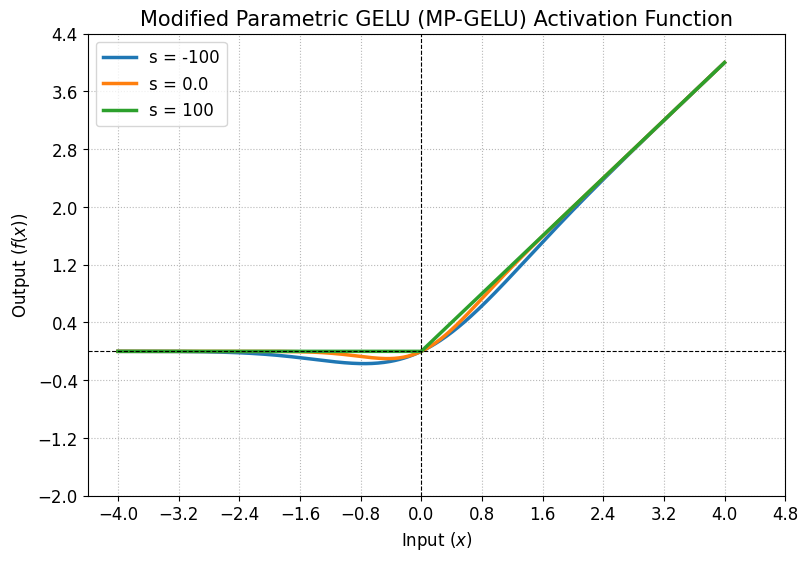

In [12]:
x_np = np.linspace(-4.0, 4.0, 400)
x_tensor = torch.tensor(x_np, dtype=torch.float32)
# s_values = np.arange(-2.0, 2.0, 0.1)
s_values = [-100, 0.0, 100, ]
plt.figure(figsize=(9, 6))

for s_val in s_values:
    activation1 = MPGELU(s_param=s_val)
    activation2 = MPGELU(s_param=s_val, use_softplus=False)
    with torch.no_grad():
        y_tensor1 = activation1(x_tensor)
        y_tensor2 = activation2(x_tensor)

    lam_val = (1.0 + F.softplus(torch.tensor(s_val, dtype=torch.float32))).item()
    plt.plot(x_np, y_tensor1.numpy(), label=f"s = {s_val}", linewidth=2.5)
    # plt.plot(x_np, y_tensor2.numpy(), label=f"s = {s_val}", linewidth=2)

# 4. Format the plot
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Modified Parametric GELU (MP-GELU) Activation Function", fontsize=15)
xticks = np.arange(-4, 5, 0.8)
plt.xticks(xticks,fontsize=12)
plt.xlabel("Input ($x$)", fontsize=12)
yticks = np.arange(-2, 5, 0.8)
plt.yticks(yticks,fontsize=12)
plt.ylabel("Output ($f(x)$)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.9)
plt.legend(fontsize=12)
plt.show()


# Data Processing

In [13]:

transformer = DataTransforms(dataset='cifar10', use_augmentation=True, use_stats=False)
train_transform = transformer.get_train_transform()
test_transform = transformer.get_test_transform()


train_data = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_data = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)


train_dataloader = DataLoader(train_data, batch_size=128, shuffle=True, num_workers=10, pin_memory=True, persistent_workers=True)
test_dataloader = DataLoader(test_data, batch_size=128, shuffle=False, num_workers=10, pin_memory=True, persistent_workers=True)

  5%|▌         | 9.34M/170M [01:05<18:57, 142kB/s]


KeyboardInterrupt: 

## Visualize Sample Images

In [14]:
fig = plt.figure(figsize=(8, 8))
rows, columns = 4, 4

for i in range(1, rows * columns + 1):
    idx = torch.randint(0, len(train_data), size=[1]).item()  # Random index
    img, label = train_data[idx][0], train_data[idx][1]
    fig.add_subplot(rows, columns, i)

    # Display image without converting to grayscale
    plt.imshow(img.permute(1, 2, 0))  # Change channels to last dimension (H, W, C)
    plt.title(train_data.classes[label])
    plt.grid(False)
    plt.axis(False)

plt.axis(False)
# plt.savefig("cifar10_dataset.jpg",dpi=800, bbox_inches="tight")
plt.show()

NameError: name 'train_data' is not defined

<Figure size 800x800 with 0 Axes>

# Model

## Set its Parameters

In [15]:
chosen_model_params = [32, 32, 'MaxPool', 64, 64, 'MaxPool', 128, 128, 128, 'MaxPool']

model = MyCNN(input_shape=3,
                  output_shape=10,
                  activation = MPGELU,
                  params = chosen_model_params).to(device)

print(summary(model=model,
        input = torch.randn(size=(3, 32, 32)).unsqueeze(dim=0)))

total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

Layer (type:depth-idx)                   Param #
MyCNN                                    --
├─Sequential: 1-1                        --
│    └─Conv2d: 2-1                       896
│    └─MPGELU: 2-2                       1
│    └─Conv2d: 2-3                       9,248
│    └─MPGELU: 2-4                       1
│    └─MaxPool2d: 2-5                    --
│    └─Conv2d: 2-6                       18,496
│    └─MPGELU: 2-7                       1
│    └─Conv2d: 2-8                       36,928
│    └─MPGELU: 2-9                       1
│    └─MaxPool2d: 2-10                   --
│    └─Conv2d: 2-11                      73,856
│    └─MPGELU: 2-12                      1
│    └─Conv2d: 2-13                      147,584
│    └─MPGELU: 2-14                      1
│    └─Conv2d: 2-15                      147,584
│    └─MPGELU: 2-16                      1
│    └─MaxPool2d: 2-17                   --
├─Sequential: 1-2                        --
│    └─Linear: 2-18                      524,544
│  

## Test Dummy Input

In [16]:
dummy_input = torch.randn(1, 3, 32, 32).to(device)
model(dummy_input)

tensor([[ 0.0143,  0.0511,  0.0420, -0.0395, -0.0507, -0.0004, -0.0422, -0.0588,
          0.0304, -0.0226]], device='cuda:0', grad_fn=<AddmmBackward0>)

# Training and Execution

## Setup loss, accuracy, and paramaters

## Mathematical Definition of Categorical Cross-Entropy

Categorical Cross-Entropy (CCE) is the standard loss function for multi-class classification. It measures the difference between two probability distributions: the actual ground-truth labels (usually one-hot encoded) and the model's predicted probabilities.

For a single sample, the loss is defined as:

$$f(y_i, \hat{y}_i) = -\sum_{i=1}^{C} y_i \log(\hat{y}_i)$$

When calculating the average loss over a batch of $N$ samples, the formula expands to:

$$f(y_i, \hat{y}_i) = -\frac{1}{N} \sum_{j=1}^{N} \sum_{i=1}^{C} y_{j,i} \log(\hat{y}_{j,i})$$

**Where:**
* $C$ = Total number of classes
* $N$ = Total number of samples in the batch
* $y_i$ (or $y_{j,i}$) = The true label (1 if the sample belongs to class $i$, and 0 for all other classes)
* $\hat{y}_i$ (or $\hat{y}_{j,i}$) = The model's predicted probability that the sample belongs to class $i$ (typically the output of a Softmax activation function)

> **Note:** Because the true labels $y_i$ are zero for all incorrect classes in one-hot encoding, the formula effectively simplifies to taking the negative log of the predicted probability for the **true** class.

In [ ]:
#Setup Loss Functions, Accuracy function
loss_fn = torch.nn.CrossEntropyLoss(label_smoothing=0.1)

#Define Accuracy Metric
def calculate_accuracy(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  accuracy = (correct / len(y_pred)) * 100
  return accuracy

##Training Parameters

num_of_epochs = 100
num_loss_steps = 5


### Gradient Norm

**Mathematical Definition**: The $\ell^2$ Norm of the Gradient. In real analysis, the small $\ell^2$ norm (standard Euclidean norm) measures the magnitude of a finite-dimensional vector in $\mathbb{R}^n$.Let $\mathbf{w} \in \mathbb{R}^n$ represent the flattened continuous vector of all trainable parameters within the neural network architecture. The gradient of the objective loss function $\mathcal{L}$ with respect to these parameters is a discrete vector composed of partial derivatives:
$$\nabla_{\mathbf{w}} \mathcal{L} = \left[ \frac{\partial \mathcal{L}}{\partial w_1}, \frac{\partial \mathcal{L}}{\partial w_2}, \dots, \frac{\partial \mathcal{L}}{\partial w_n} \right]^T$$

The $\ell^2$ norm of this gradient vector, denoted as $\Vert{} \nabla_{\mathbf{w}} \mathcal{L} \Vert{}_{\ell^2}$ or simply $\Vert{} \nabla_{\mathbf{w}} \mathcal{L} \Vert{}_2$, is defined as the square root of the sum of its squared coordinate components:$$\Vert{} \nabla_{\mathbf{w}} \mathcal{L} \Vert{}_2 = \sqrt{ \sum_{i=1}^{n} \left( \frac{\partial \mathcal{L}}{\partial w_i} \right)^2 }$$In the context of empirical risk minimization, bounding this sequence of finite sums guarantees that gradient updates remain stable and prevents the parameter vector from diverging during optimization.


**IMPORTANT NOTE**

In real and functional analysis, the capital $L^p$ spaces denote spaces of measurable functions, where the norm is evaluated via continuous integration, such as $\Vert{}f\Vert{}_{L^2} = \left( \int \vert{}f(x)\vert{}^2 dx \right)^{1/2}$. The lowercase $\ell^p$ spaces apply to discrete sequences or finite-dimensional coordinate vectors, where the norm is evaluated via discrete summation. Since the gradient of a neural network's loss with respect to its parameters, $\nabla_{\mathbf{w}} \mathcal{L}$, is a finite-dimensional vector of discrete scalar derivatives rather than a continuous mathematical function, finding its magnitude requires summing the squares of its individual components. You are completely correct: we use the small $\ell^2$ norm precisely because we are operating on discrete Euclidean vectors, not continuous functions.

## Execution and Saving

In [10]:
torch.manual_seed(143)
activation_dict = {
    "PGELU": PGELU,
    "MP_GELU": MPGELU,
    "ReLU": torch.nn.ReLU,
    "GELU": torch.nn.GELU,
    "LeakyReLU": torch.nn.LeakyReLU
}

all_results = {}

for act_name, act_fn in activation_dict.items():
    print(f"\n=======================================================")
    print(f"       TRAINING WITH ACTIVATION: {act_name}")
    print(f"=======================================================")

    model = MyCNN(input_shape=3, output_shape=10, activation=act_fn, params=chosen_model_params).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)

    trainer = Trainer(model=model, loss_fn=loss_fn, optimizer=optimizer,
                      calculate_accuracy=calculate_accuracy, device=device, loss_steps=num_loss_steps)

    results = {
        "train_loss": [],
        "train_accu": [],
        "test_loss": [],
        "test_accu": [],
        "activation_params": {},
        "grad_norm": []  # Initialize an empty list to store gradient norms
    }

    start_time = time.perf_counter()

    for epoch in tqdm(range(num_of_epochs), desc=f"Training {act_name}"):
        if epoch % num_loss_steps == 0:
            print(f"Epoch: {epoch} \n =====================================================================")
        train_loss, train_accu, norm = trainer.train(data_loader=train_dataloader, epoch=epoch)
        test_loss, test_accu = trainer.test(data_loader=test_dataloader, epoch=epoch)

        results["train_loss"].append(train_loss)
        results["train_accu"].append(train_accu)
        results["test_loss"].append(test_loss)
        results["test_accu"].append(test_accu)
        results["grad_norm"].append(norm)

        # Track dynamic activation parameters
        for name, param in model.named_parameters():
            if 'alpha_param' in name or 'beta_param' in name or 's_param' in name:
                if name not in results.setdefault("activation_params", {}):
                    results["activation_params"][name] = []
                results["activation_params"][name].append(param.item())

    total_time = time.perf_counter() - start_time
    results["total_runtime"] = total_time
    all_results[act_name] = results

    # Save Model Checkpoint
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'results': results,
        'total_runtime': total_time,
        'activation_name': act_name
    }

    save_dir = "model_trained_params_new"
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"chkpt2_{act_name}.pth")

    torch.save(checkpoint, save_path)
    print(f"Saved model state to {save_path}")


       TRAINING WITH ACTIVATION: PGELU


Training PGELU:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 1.99738 | Training Accuracy: 28.61973%
Test Loss 1.68541 | Test Accuracy 44.77848%
Epoch: 5 
Training Loss: 1.30528 | Training Accuracy: 64.23713%
Test Loss 1.14899 | Test Accuracy 71.57832%
Epoch: 10 
Training Loss: 1.18211 | Training Accuracy: 70.00280%
Test Loss 1.01567 | Test Accuracy 78.09533%
Epoch: 15 
Training Loss: 1.12959 | Training Accuracy: 72.67943%
Test Loss 0.98855 | Test Accuracy 79.83584%
Epoch: 20 
Training Loss: 1.08156 | Training Accuracy: 74.83256%
Test Loss 0.95807 | Test Accuracy 80.98299%
Epoch: 25 
Training Loss: 1.04809 | Training Accuracy: 76.21244%
Test Loss 0.91303 | Test Accuracy 82.57516%
Epoch: 30 
Training Loss: 1.01819 | Training Accuracy: 77.63187%
Test Loss 0.88928 | Test Accuracy 83.56408%
Epoch: 35 
Training Loss: 0.99497 | Training Accuracy: 78.85750%
Test Loss 0.89752 | Test Accuracy 83.87065%
Epoch: 40 
Training Loss: 0.98498 | Training Accuracy: 79.15321%
Test Loss 0.89178 | Test Accuracy 84.05854%
Epoch: 45 
Training L

Training MP_GELU:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.10557 | Training Accuracy: 23.34399%
Test Loss 1.89018 | Test Accuracy 34.25633%
Epoch: 5 
Training Loss: 1.32167 | Training Accuracy: 63.04508%
Test Loss 1.12596 | Test Accuracy 72.99248%
Epoch: 10 
Training Loss: 1.12840 | Training Accuracy: 72.30619%
Test Loss 0.98687 | Test Accuracy 79.11392%
Epoch: 15 
Training Loss: 1.04823 | Training Accuracy: 75.92191%
Test Loss 0.92337 | Test Accuracy 82.17959%
Epoch: 20 
Training Loss: 0.99347 | Training Accuracy: 78.49984%
Test Loss 0.89417 | Test Accuracy 83.37619%
Epoch: 25 
Training Loss: 0.95714 | Training Accuracy: 80.02438%
Test Loss 0.87982 | Test Accuracy 83.86076%
Epoch: 30 
Training Loss: 0.92849 | Training Accuracy: 81.39066%
Test Loss 0.87356 | Test Accuracy 84.60245%
Epoch: 35 
Training Loss: 0.90646 | Training Accuracy: 82.35134%
Test Loss 0.86013 | Test Accuracy 85.26503%
Epoch: 40 
Training Loss: 0.89269 | Training Accuracy: 82.98394%
Test Loss 0.84483 | Test Accuracy 85.47271%
Epoch: 45 
Training L

...

Epoch: 0 
Training Loss: 2.10477 | Training Accuracy: 23.28165%
Test Loss 1.86824 | Test Accuracy 35.67049%
Epoch: 5 
Training Loss: 1.57711 | Training Accuracy: 50.26055%
Test Loss 1.43189 | Test Accuracy 56.96203%
Epoch: 10 
Training Loss: 1.37182 | Training Accuracy: 60.26415%
Test Loss 1.22301 | Test Accuracy 67.79074%
Epoch: 15 
Training Loss: 1.26109 | Training Accuracy: 65.86877%
Test Loss 1.12138 | Test Accuracy 72.74525%
Epoch: 20 
Training Loss: 1.18811 | Training Accuracy: 69.26311%
Test Loss 1.05574 | Test Accuracy 75.79114%
Epoch: 25 
Training Loss: 1.14818 | Training Accuracy: 71.13491%
Test Loss 1.02991 | Test Accuracy 76.98774%
Epoch: 30 
Training Loss: 1.11596 | Training Accuracy: 72.55994%
Test Loss 1.01502 | Test Accuracy 77.64043%
Epoch: 35 
Training Loss: 1.08483 | Training Accuracy: 73.90066%
Test Loss 1.00023 | Test Accuracy 78.14478%
Epoch: 40 
Training Loss: 1.06766 | Training Accuracy: 74.80778%
Test Loss 0.99557 | Test Accuracy 78.50079%
Epoch: 45 
Training L

Training GELU:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.10547 | Training Accuracy: 22.45724%
Test Loss 1.82529 | Test Accuracy 38.45926%
Epoch: 5 
Training Loss: 1.37241 | Training Accuracy: 60.87516%
Test Loss 1.16514 | Test Accuracy 71.17286%
Epoch: 10 
Training Loss: 1.17055 | Training Accuracy: 70.30730%
Test Loss 1.01334 | Test Accuracy 78.25356%
Epoch: 15 
Training Loss: 1.09305 | Training Accuracy: 73.99936%
Test Loss 0.95514 | Test Accuracy 81.03244%
Epoch: 20 
Training Loss: 1.04222 | Training Accuracy: 76.28597%
Test Loss 0.92851 | Test Accuracy 82.14003%
Epoch: 25 
Training Loss: 1.00708 | Training Accuracy: 77.84247%
Test Loss 0.91386 | Test Accuracy 82.82239%
Epoch: 30 
Training Loss: 0.98058 | Training Accuracy: 79.18398%
Test Loss 0.90732 | Test Accuracy 83.31685%
Epoch: 35 
Training Loss: 0.95732 | Training Accuracy: 80.44637%
Test Loss 0.88609 | Test Accuracy 83.99921%
Epoch: 40 
Training Loss: 0.93962 | Training Accuracy: 81.05059%
Test Loss 0.88494 | Test Accuracy 84.23655%
Epoch: 45 
Training L

Training LeakyReLU:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch: 0 
Training Loss: 2.11014 | Training Accuracy: 22.19110%
Test Loss 1.83521 | Test Accuracy 36.50119%
Epoch: 5 
Training Loss: 1.46718 | Training Accuracy: 55.63899%
Test Loss 1.28774 | Test Accuracy 64.33940%
Epoch: 10 
Training Loss: 1.24626 | Training Accuracy: 66.48697%
Test Loss 1.15976 | Test Accuracy 70.79707%
Epoch: 15 
Training Loss: 1.13670 | Training Accuracy: 71.62604%
Test Loss 1.02962 | Test Accuracy 77.12619%
Epoch: 20 
Training Loss: 1.07769 | Training Accuracy: 74.33264%
Test Loss 0.96963 | Test Accuracy 79.59850%
Epoch: 25 
Training Loss: 1.04059 | Training Accuracy: 76.12532%
Test Loss 0.96052 | Test Accuracy 80.39953%
Epoch: 30 
Training Loss: 1.00687 | Training Accuracy: 77.63027%
Test Loss 0.93169 | Test Accuracy 81.89280%
Epoch: 35 
Training Loss: 0.98692 | Training Accuracy: 78.64650%
Test Loss 0.91458 | Test Accuracy 82.36748%
Epoch: 40 
Training Loss: 0.96799 | Training Accuracy: 79.58760%
Test Loss 0.89633 | Test Accuracy 83.45530%
Epoch: 45 
Training L

# Loading the trained model params


In [17]:
activation_dict = {
    "MP_GELU": MPGELU,
    "PGELU": PGELU,
    "ReLU": torch.nn.ReLU,
    "GELU": torch.nn.GELU,
    "LeakyReLU": torch.nn.LeakyReLU
}


# Initialize LoadedModel with the correct initial_fileName and checkpoint_dir
loader = LoadedModel(
    activation_dict=activation_dict,
    model_params=chosen_model_params,
    initial_fileName="chkpt2",
    checkpoint_dir="model_trained_params_new",
    device=device
)

# Run it
my_models = loader.load_checkpoints()


       EVALUATING ACTIVATION: MP_GELU
Loaded trained model for MP_GELU from model_trained_params_new/chkpt2_MP_GELU.pth

       EVALUATING ACTIVATION: PGELU
Loaded trained model for PGELU from model_trained_params_new/chkpt2_PGELU.pth

       EVALUATING ACTIVATION: ReLU
Loaded trained model for ReLU from model_trained_params_new/chkpt2_ReLU.pth

       EVALUATING ACTIVATION: GELU
Loaded trained model for GELU from model_trained_params_new/chkpt2_GELU.pth

       EVALUATING ACTIVATION: LeakyReLU
Loaded trained model for LeakyReLU from model_trained_params_new/chkpt2_LeakyReLU.pth


# Evaluation

## Plotting

In [18]:
to_plot = {
    "MP_GELU":   {"results": my_models["MP_GELU"]["results"],   "linewidth": 3.0, "color": "#000000"}, # Jet Black
    "PGELU":     {"results": my_models["PGELU"]["results"],     "linewidth": 2.0, "color": "#E62937"}, # Strong Red
    "ReLU":      {"results": my_models["ReLU"]["results"],      "linewidth": 2.0, "color": "#009E73"}, # Teal
    "GELU":      {"results": my_models["GELU"]["results"],      "linewidth": 2.0, "color": "#4363D8"}, # Royal Blue
    "LeakyReLU": {"results": my_models["LeakyReLU"]["results"], "linewidth": 2.0, "color": "#F58231"}  # Bright Orange
}

### Evolution of Learnable Parameters

#### $\alpha$ and $\beta$ of PGELU

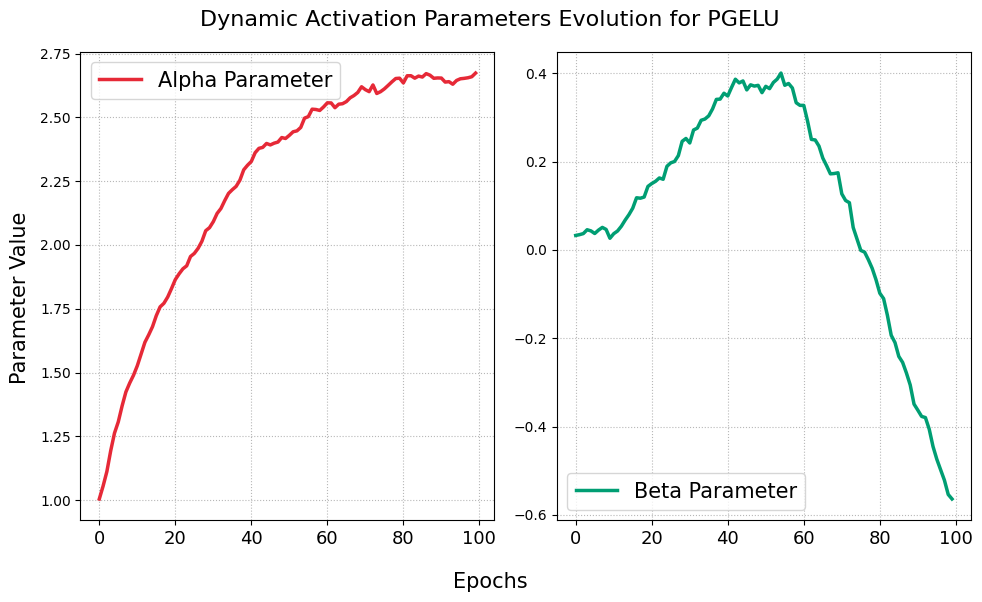

In [19]:
alpha = my_models["PGELU"]["results"]["activation_params"]["conv_layers.1.alpha_param"]
beta = my_models["PGELU"]["results"]["activation_params"]["conv_layers.1.beta_param"]

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
# Alpha Plot
ax[0].plot(alpha, label="Alpha Parameter", color="#E62937", linewidth=2.5)
# ax[0].set_title("Alpha Parameter Evolution", fontsize=14)
ax[0].grid(True, linestyle=':', alpha=0.9)
ax[0].tick_params(axis='x', labelsize=13)
ax[0].legend(fontsize=15)
# Beta Plot
ax[1].plot(beta, label="Beta Parameter", color="#009E73", linewidth=2.5)
# ax[1].set_title("Beta Parameter Evolution", fontsize=14)
ax[1].grid(True, linestyle=':', alpha=0.9)
ax[1].tick_params(axis='x', labelsize=13)
ax[1].legend(fontsize=15)


fig.supxlabel("Epochs", fontsize=15)
fig.supylabel("Parameter Value", fontsize=15)
fig.suptitle("Dynamic Activation Parameters Evolution for PGELU", fontsize=16)

plt.tight_layout()
plt.show()

#### $\lambda$ of MPGELU

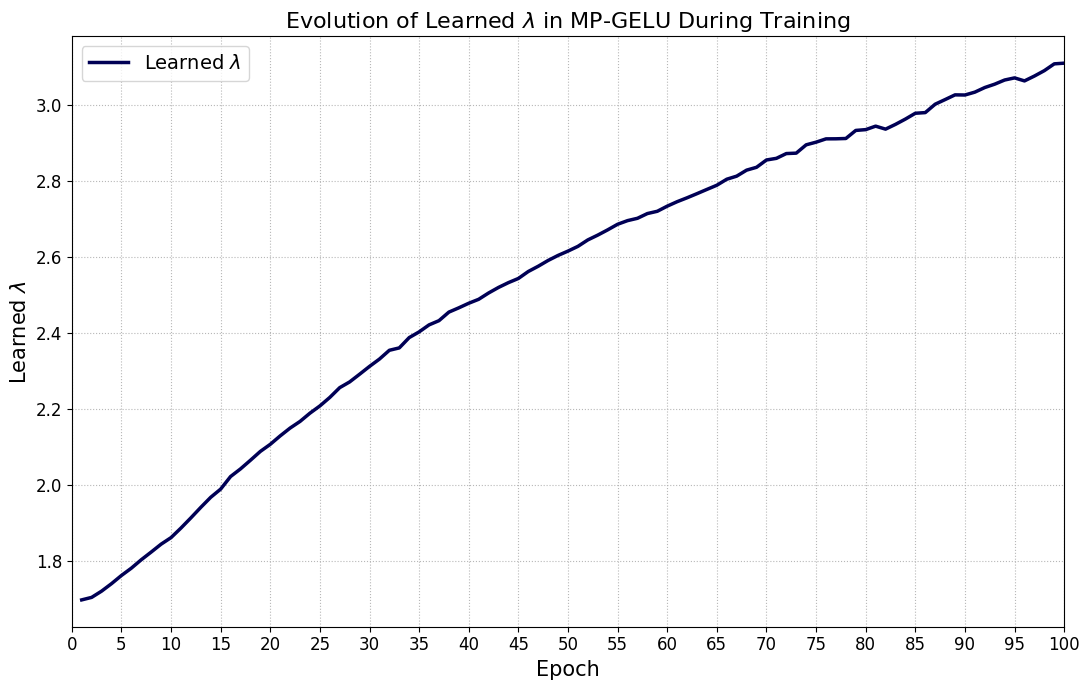

In [20]:
# ============================================================
# MP-GELU LEARNED LAMBDA EVOLUTION
# ============================================================

params_dict = my_models["MP_GELU"]["results"]["activation_params"]

s_vals = params_dict["conv_layers.1.s_param"]

# Convert stored s values to tensor
s_values = torch.tensor(
    s_vals,
    dtype=torch.float32,
    device=device
)

# Use the same formulation as MPGELU
lam = 1.0 + F.softplus(s_values)

# Epoch numbers
epochs = np.arange(1, len(s_vals) + 1)

plt.figure(figsize=(11, 7))

plt.plot(
    epochs,
    lam.detach().cpu().numpy(),
    linewidth=2.5,
    color="#000055",
    label=r"Learned $\lambda$"
)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel(r"Learned $\lambda$", fontsize=15)
plt.title(r"Evolution of Learned $\lambda$ in MP-GELU During Training", fontsize=16)

plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5), fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, linestyle=":", alpha=0.9)
plt.legend(fontsize=14)

plt.tight_layout()
plt.show()

### Train Loss Curves

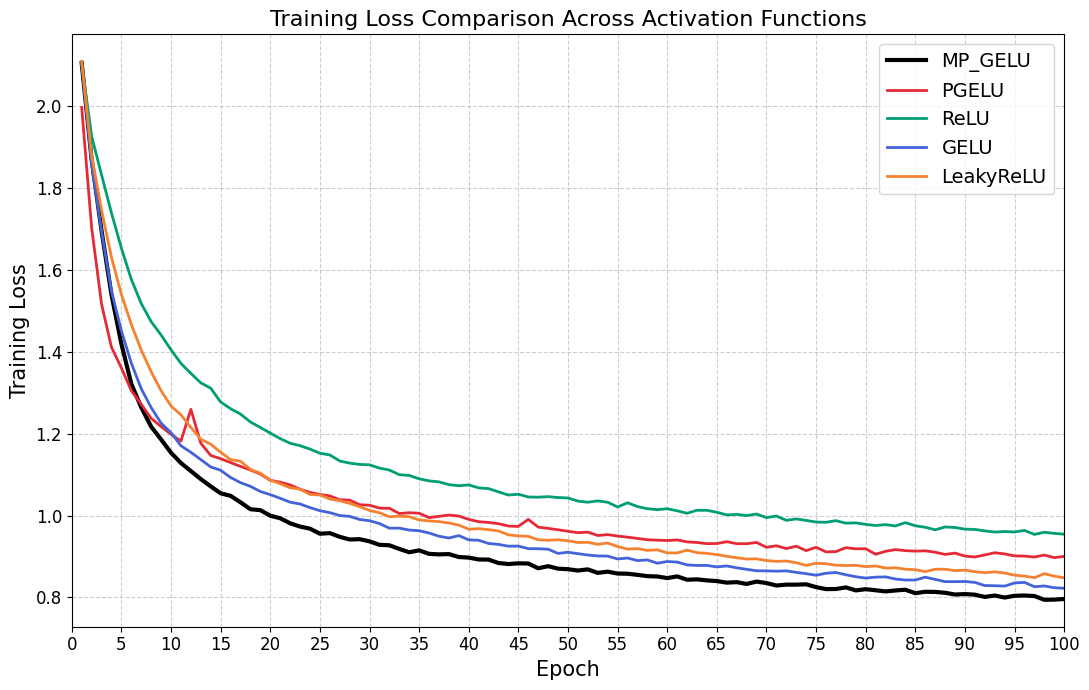

In [21]:
# ============================================================
# TRAINING LOSS COMPARISON
# ============================================================

plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]

    epochs = np.arange(
        1,
        len(plot_results["train_loss"]) + 1
    )

    plt.plot(
        epochs,
        plot_results["train_loss"],
        linewidth=property.get("linewidth", 1.0),
        linestyle=property.get("linestyle", "-"),
        label=act_name,
        color=property["color"]
    )

plt.legend(loc="upper right", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Training Loss", fontsize=15)
plt.title(
    "Training Loss Comparison Across Activation Functions",
    fontsize=16
)

plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5), fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### Test Loss Curves

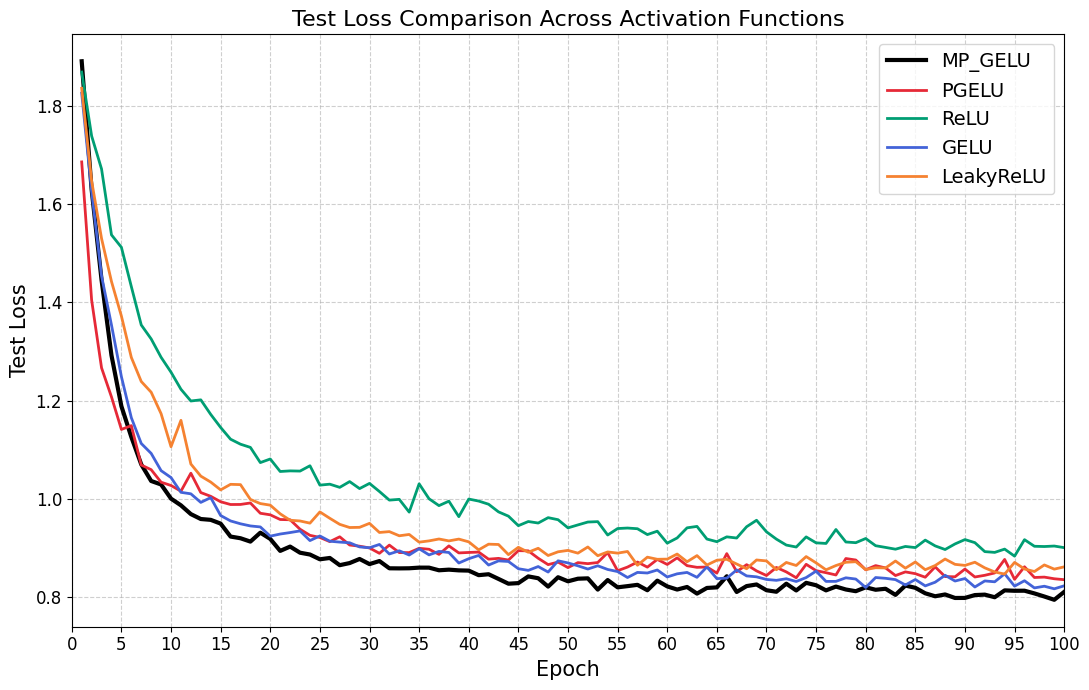

In [22]:
# ============================================================
# TEST LOSS COMPARISON
# ============================================================

plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]

    epochs = np.arange(
        1,
        len(plot_results["test_loss"]) + 1
    )

    plt.plot(
        epochs,
        plot_results["test_loss"],
        linewidth=property.get("linewidth", 1.0),
        linestyle=property.get("linestyle", "-"),
        label=act_name,
        color=property["color"]
    )

plt.legend(loc="upper right", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Test Loss", fontsize=15)
plt.title(
    "Test Loss Comparison Across Activation Functions",
    fontsize=16
)

plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5), fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

### Training Accuracy

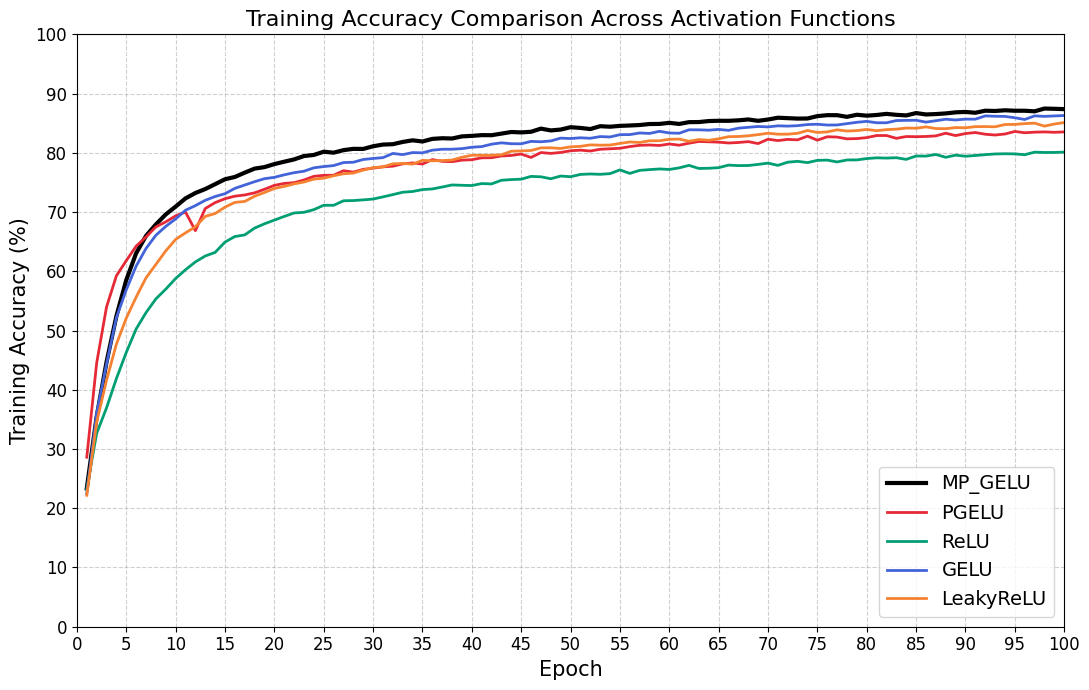

In [23]:
# ============================================================
# TRAINING ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]

    epochs = np.arange(
        1,
        len(plot_results["train_accu"]) + 1
    )

    plt.plot(
        epochs,
        plot_results["train_accu"],
        linewidth=property.get("linewidth", 1.0),
        linestyle=property.get("linestyle", "-"),
        label=act_name,
        color=property["color"]
    )

plt.legend(loc="lower right", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Training Accuracy (%)", fontsize=15)
plt.title(
    "Training Accuracy Comparison Across Activation Functions",
    fontsize=16
)

plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5), fontsize=12)
plt.yticks(np.arange(0, 101, 10), fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

### Test Accuracy

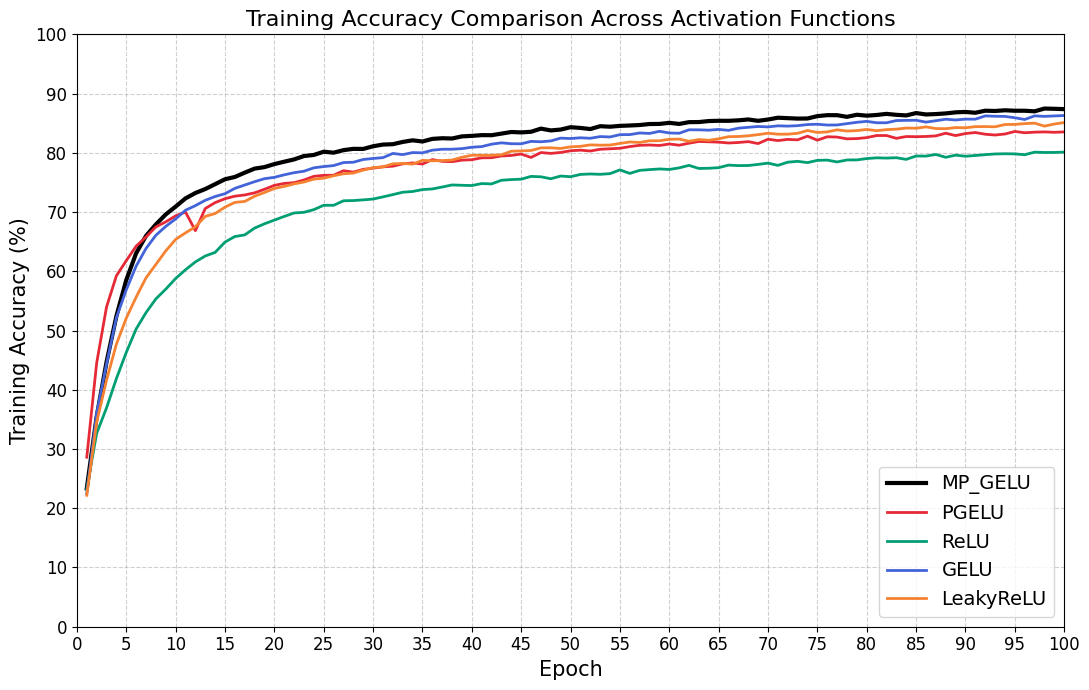

In [24]:
# ============================================================
# TRAINING ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(11, 7))

for act_name, property in to_plot.items():
    plot_results = property["results"]

    epochs = np.arange(
        1,
        len(plot_results["train_accu"]) + 1
    )

    plt.plot(
        epochs,
        plot_results["train_accu"],
        linewidth=property.get("linewidth", 1.0),
        linestyle=property.get("linestyle", "-"),
        label=act_name,
        color=property["color"]
    )

plt.legend(loc="lower right", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)

plt.xlabel("Epoch", fontsize=15)
plt.ylabel("Training Accuracy (%)", fontsize=15)
plt.title(
    "Training Accuracy Comparison Across Activation Functions",
    fontsize=16
)

plt.xlim(1, 100)
plt.xticks(np.arange(0, 101, 5), fontsize=12)
plt.yticks(np.arange(0, 101, 10), fontsize=12)
plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# $F_{1}$ Scores
**Mathematical Definition of the $F_1$ Score**

The $F_1$ score is the harmonic mean of Precision and Recall. It provides a single metric that balances both false positives and false negatives, making it particularly useful for evaluating models on imbalanced datasets.

The general formula is defined as:

$$F_1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

To calculate the $F_1$ score, you must first calculate **Precision** and **Recall**:

* **Precision** measures the proportion of positive predictions that were actually correct:
  $$\text{Precision} = \frac{TP}{TP + FP}$$

* **Recall** (also known as Sensitivity) measures the proportion of actual positives that were identified correctly:
  $$\text{Recall} = \frac{TP}{TP + FN}$$

By substituting Precision and Recall back into the original equation, the $F_1$ score can be expressed directly in terms of prediction outcomes:

$$F_1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

**Where:**
* $TP$ = **True Positives** (Model correctly predicts the positive class)
* $FP$ = **False Positives** (Model incorrectly predicts the positive class)
* $FN$ = **False Negatives** (Model incorrectly predicts the negative class)

In [19]:
f1_results = {}

print("Calculating F1 Scores...")
print("========================")

for act_name, model_data in my_models.items():
    model = model_data["model"]
    model.eval()  # Ensure the model is in evaluation mode

    all_preds = []
    all_targets = []

    with torch.inference_mode():
        # Assuming you have your test_dataloader ready
        for inputs, targets in test_dataloader:
            inputs = inputs.to(device)

            # Get predictions
            outputs = model(inputs)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.numpy())

    f1 = f1_score(all_targets, all_preds, average='macro')
    f1_results[act_name] = f1

    print(f"{act_name: >10}: {f1:.4f}")

Calculating F1 Scores...
   MP_GELU: 0.8764
     PGELU: 0.8679
      ReLU: 0.8329
      GELU: 0.8708
 LeakyReLU: 0.8555


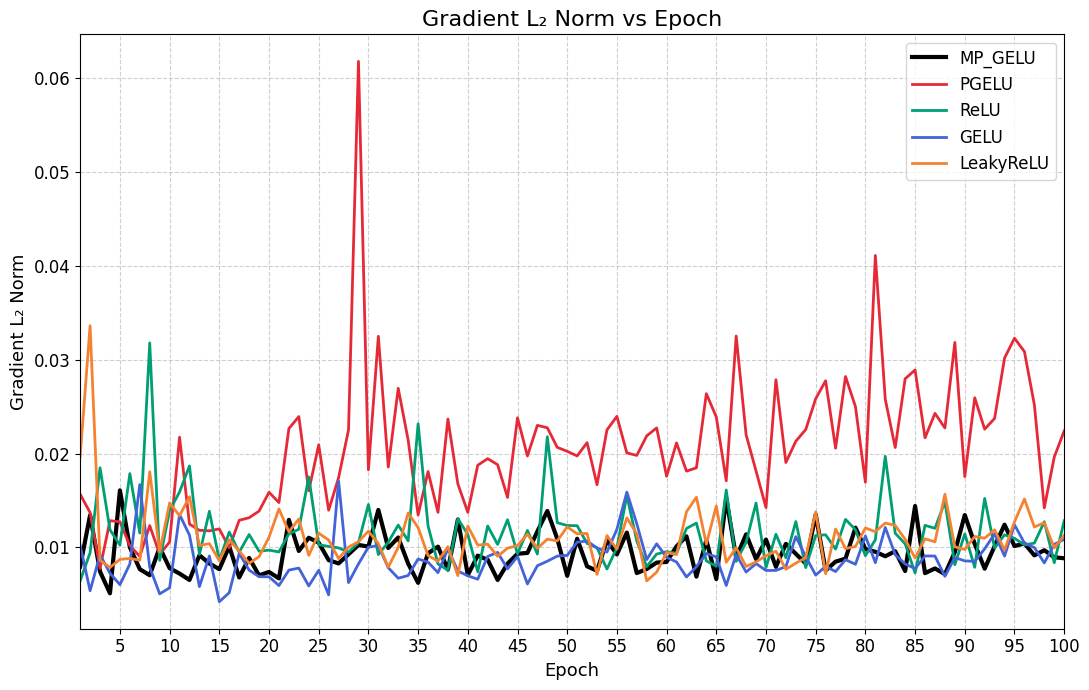

In [20]:
# ============================================================
# GRADIENT L2 NORM VS EPOCH
# ============================================================

plt.figure(figsize=(11, 7))

for act_name, properties in to_plot.items():

    plot_results = properties["results"]

    epochs = np.arange(1, len(plot_results["grad_norm"]) + 1)

    plt.plot(
        epochs,
        plot_results["grad_norm"],
        linewidth=properties["linewidth"],
        linestyle="-",
        label=act_name,
        color=properties["color"]
    )

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Gradient L₂ Norm", fontsize=13)

plt.title(
    "Gradient L₂ Norm vs Epoch",
    fontsize=16
)

plt.legend(
    loc="upper right",
    fontsize=12
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.6
)

plt.xticks(
    np.arange(0, 101, 5),
    fontsize=12
)

plt.yticks(fontsize=12)

plt.xlim(1, 100)

plt.tight_layout()
plt.show()

In [21]:
import numpy as np

print("=" * 80)
print("Gradient L₂ Norms by Epoch")
print("=" * 80)

for act_name, results in all_results.items():
    print(f"\n{'=' * 80}")
    print(f"ACTIVATION: {act_name}")
    print(f"{'=' * 80}")

    grad_norms = np.array(results["grad_norm"], dtype=float)

    # Print every epoch
    for epoch, grad_norm in enumerate(grad_norms, start=1):
        print(f"Epoch {epoch:3d}: Gradient L₂ Norm = {grad_norm:.6f}")

    # Calculate statistics
    mean_grad = np.mean(grad_norms)
    std_grad = np.std(grad_norms, ddof=1)
    min_grad = np.min(grad_norms)
    max_grad = np.max(grad_norms)

    print(f"\n{'-' * 80}")
    print(f"SUMMARY — {act_name}")
    print(f"{'-' * 80}")
    print(f"Average Gradient L₂ Norm : {mean_grad:.6f} ± {std_grad:.6f}")
    print(f"Minimum Gradient L₂ Norm : {min_grad:.6f}")
    print(f"Maximum Gradient L₂ Norm : {max_grad:.6f}")

Gradient L₂ Norms by Epoch

ACTIVATION: PGELU
Epoch   1: Gradient L₂ Norm = 0.015675
Epoch   2: Gradient L₂ Norm = 0.013710
Epoch   3: Gradient L₂ Norm = 0.007768
Epoch   4: Gradient L₂ Norm = 0.012854
Epoch   5: Gradient L₂ Norm = 0.012732
Epoch   6: Gradient L₂ Norm = 0.010193
Epoch   7: Gradient L₂ Norm = 0.009043
Epoch   8: Gradient L₂ Norm = 0.012325
Epoch   9: Gradient L₂ Norm = 0.009251
Epoch  10: Gradient L₂ Norm = 0.010583
Epoch  11: Gradient L₂ Norm = 0.021749
Epoch  12: Gradient L₂ Norm = 0.012489
Epoch  13: Gradient L₂ Norm = 0.011824
Epoch  14: Gradient L₂ Norm = 0.011770
Epoch  15: Gradient L₂ Norm = 0.011971
Epoch  16: Gradient L₂ Norm = 0.009957
Epoch  17: Gradient L₂ Norm = 0.012890
Epoch  18: Gradient L₂ Norm = 0.013167
Epoch  19: Gradient L₂ Norm = 0.013876
Epoch  20: Gradient L₂ Norm = 0.015881
Epoch  21: Gradient L₂ Norm = 0.014783
Epoch  22: Gradient L₂ Norm = 0.022671
Epoch  23: Gradient L₂ Norm = 0.023954
Epoch  24: Gradient L₂ Norm = 0.016041
Epoch  25: Gradien